<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/hw4_CSCI4170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nisargchodavadiya/daily-gold-price-20152021-time-series")

print("Path to dataset files:", path)

100%|██████████| 52.4k/52.4k [00:00<00:00, 33.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nisargchodavadiya/daily-gold-price-20152021-time-series/versions/8


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import math
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

csv_file_name = csv_files[0]
full_csv_path = os.path.join(path, csv_file_name)

data = pd.read_csv(full_csv_path)

data = data.sort_values('Date')

data.reset_index(drop=True, inplace=True)

print(data.head(5))

         Date  Price   Open   High    Low  Volume  Chg%
0  2014-01-01  29542  29435  29598  29340    2930  0.25
1  2014-01-02  29975  29678  30050  29678    3140  1.47
2  2014-01-03  29727  30031  30125  29539    3050 -0.83
3  2014-01-04  29279  29279  29279  29279       0 -1.51
4  2014-01-06  29119  29300  29395  29051   24380 -0.55


In [ ]:
from sklearn.preprocessing import MinMaxScaler

close_values = data['High'].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(close_values)

total_length = len(scaled_values)
train_end = int(total_length * 0.7)
val_end = int(total_length * 0.85)

train_data = scaled_values[:train_end]
val_data = scaled_values[train_end:val_end]
test_data = scaled_values[val_end:]

def create_sequences(dataset, seq_length=5):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        seq_x = dataset[i : i + seq_length]
        seq_y = dataset[i + seq_length]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

sequence_length = 5
X_train, y_train = create_sequences(train_data, sequence_length)
X_val, y_val = create_sequences(val_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

print("Train set shapes:", X_train.shape)
print("Val set shapes:  ", X_val.shape)
print("Test set shapes: ", X_test.shape)

Train set shapes: (2167, 5, 1)
Val set shapes:   (461, 5, 1)
Test set shapes:  (461, 5, 1)


In [ ]:
class GoldDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = GoldDataset(X_train, y_train)
val_dataset = GoldDataset(X_val, y_val)
test_dataset = GoldDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 136
Number of validation batches: 29
Number of test batches: 29


##  TASK 2.1 Implement RNN

In [ ]:
class BasicRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(BasicRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, hn = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

basic_rnn_model = BasicRNNModel(input_size=1, hidden_size=16, num_layers=2, output_size=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(basic_rnn_model.parameters(), lr=0.01)

Epoch [1/10], Train Loss: 0.0023, Val Loss: 0.0000
Epoch [2/10], Train Loss: 0.0000, Val Loss: 0.0002
Epoch [3/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [4/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [5/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [6/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [7/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [8/10], Train Loss: 0.0000, Val Loss: 0.0002
Epoch [9/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [10/10], Train Loss: 0.0000, Val Loss: 0.0002


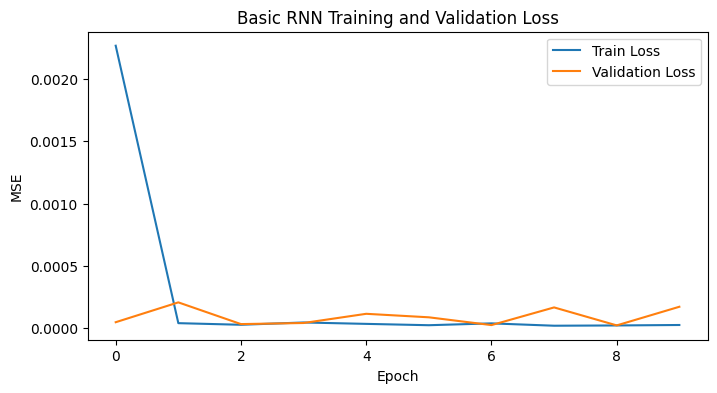

In [ ]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=10):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_train_losses = []
        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_train_losses.append(loss.item())

        train_loss = np.mean(batch_train_losses)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                y_val_pred = model(X_val_batch)
                val_loss = loss_fn(y_val_pred, y_val_batch)
                batch_val_losses.append(val_loss.item())
        val_loss_mean = np.mean(batch_val_losses)
        val_losses.append(val_loss_mean)

        if (epoch+1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss_mean:.4f}")

    return train_losses, val_losses

# Train the basic RNN
epochs = 10
train_losses_rnn, val_losses_rnn = train_model(basic_rnn_model, train_loader, val_loader, loss_fn, optimizer, epochs)

# Plot losses
plt.figure(figsize=(8,4))
plt.plot(train_losses_rnn, label='Train Loss')
plt.plot(val_losses_rnn, label='Validation Loss')
plt.title('Basic RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

Test MSE (scaled): 0.018585121869270145
Test MSE (original scale): 232129120.0


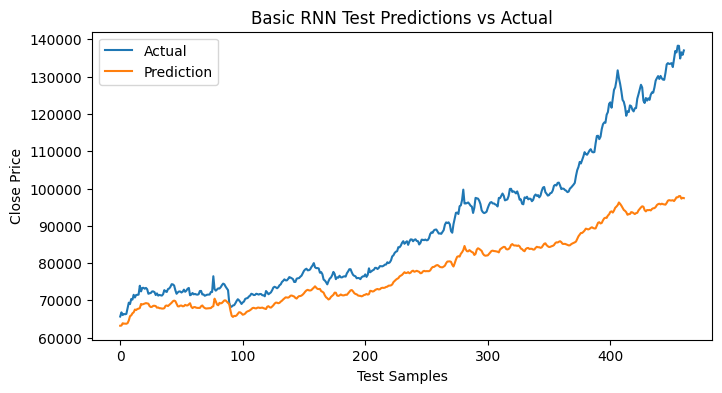

In [ ]:
def evaluate_model(model, data_loader, loss_fn):
    model.eval()
    losses = []
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())

            predictions.append(y_pred.numpy())
            actuals.append(y_batch.numpy())

    avg_loss = np.mean(losses)
    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)

    return avg_loss, predictions, actuals

test_loss_rnn, test_preds_rnn, test_actuals_rnn = evaluate_model(basic_rnn_model, test_loader, loss_fn)
print("Test MSE (scaled):", test_loss_rnn)

# Invert scaling:
test_preds_rnn_inv = scaler.inverse_transform(test_preds_rnn)
test_actuals_rnn_inv = scaler.inverse_transform(test_actuals_rnn)

mse_inv = np.mean((test_preds_rnn_inv - test_actuals_rnn_inv)**2)
print("Test MSE (original scale):", mse_inv)

# Let's do a quick plot
plt.figure(figsize=(8,4))
plt.plot(test_actuals_rnn_inv, label='Actual')
plt.plot(test_preds_rnn_inv, label='Prediction')
plt.title('Basic RNN Test Predictions vs Actual')
plt.xlabel('Test Samples')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## Task 2.2 Implement LSTM model

Epoch [1/10], Train Loss: 0.0043, Val Loss: 0.0054
Epoch [2/10], Train Loss: 0.0002, Val Loss: 0.0000
Epoch [3/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [4/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [5/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [6/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [7/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [8/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [9/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [10/10], Train Loss: 0.0000, Val Loss: 0.0000

LSTM Test MSE (scaled): 0.010954564968164176
LSTM Test MSE (original scale): 136372960.0


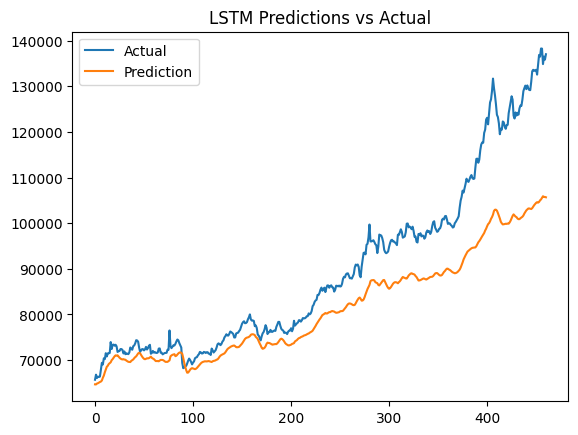

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # h0, c0 init
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

lstm_model = LSTMModel(input_size=1, hidden_size=16, num_layers=1, output_size=1)
loss_fn_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

train_losses_lstm, val_losses_lstm = train_model(lstm_model, train_loader, val_loader, loss_fn_lstm, optimizer_lstm, epochs=10)

# Evaluate on test
test_loss_lstm, test_preds_lstm, test_actuals_lstm = evaluate_model(lstm_model, test_loader, loss_fn_lstm)
test_preds_lstm_inv = scaler.inverse_transform(test_preds_lstm)
test_actuals_lstm_inv = scaler.inverse_transform(test_actuals_lstm)
mse_lstm_inv = np.mean((test_preds_lstm_inv - test_actuals_lstm_inv)**2)
print("\nLSTM Test MSE (scaled):", test_loss_lstm)
print("LSTM Test MSE (original scale):", mse_lstm_inv)

# Plot
plt.figure()
plt.title("LSTM Predictions vs Actual")
plt.plot(test_actuals_lstm_inv, label='Actual')
plt.plot(test_preds_lstm_inv, label='Prediction')
plt.legend()
plt.show()

## Task 2.2 GRU Model

Epoch [1/10], Train Loss: 0.0062, Val Loss: 0.0120
Epoch [2/10], Train Loss: 0.0004, Val Loss: 0.0001
Epoch [3/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [4/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [5/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [6/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [7/10], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [8/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [9/10], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [10/10], Train Loss: 0.0000, Val Loss: 0.0001

GRU Test MSE (scaled): 0.005208445740020673
GRU Test MSE (original scale): 65146264.0


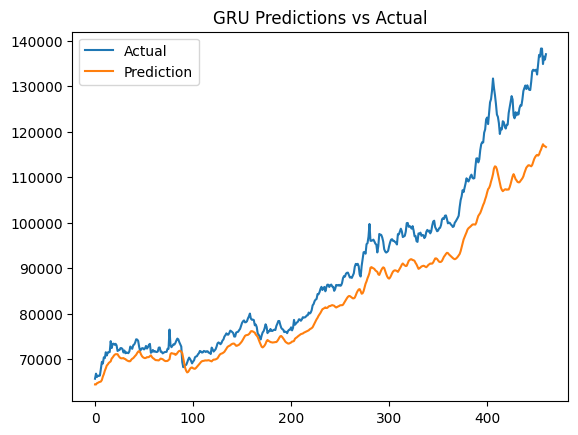

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, hn = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

gru_model = GRUModel(input_size=1, hidden_size=16, num_layers=1, output_size=1)
loss_fn_gru = nn.MSELoss()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)

train_losses_gru, val_losses_gru = train_model(gru_model, train_loader, val_loader, loss_fn_gru, optimizer_gru, epochs=10)

# Evaluate on test
test_loss_gru, test_preds_gru, test_actuals_gru = evaluate_model(gru_model, test_loader, loss_fn_gru)
test_preds_gru_inv = scaler.inverse_transform(test_preds_gru)
test_actuals_gru_inv = scaler.inverse_transform(test_actuals_gru)
mse_gru_inv = np.mean((test_preds_gru_inv - test_actuals_gru_inv)**2)
print("\nGRU Test MSE (scaled):", test_loss_gru)
print("GRU Test MSE (original scale):", mse_gru_inv)

# Plot
plt.figure()
plt.title("GRU Predictions vs Actual")
plt.plot(test_actuals_gru_inv, label='Actual')
plt.plot(test_preds_gru_inv, label='Prediction')
plt.legend()
plt.show()

## 2.3 Explaination


A Feed-Forward Network (FNN) can be used for time series prediction by converting sequential data into a fixed-size input using a windowing approach. Instead of processing data step-by-step like recurrent models, the FNN takes a set number of past values and flattens them into a single vector (aka [price(t-1), price(t-2), price(t-3), price(t-4), price(t-5)]`) to predict next value. However, unlike RNNs, LSTMs, or GRUs, FNNs do not maintain memory of previous time steps and therefore cannot explicitly capture temporal order or long-term dependencies.

# TASK 3 Implement word embeddings

In [1]:
!pip install gensim
import gensim.downloader as api

print("Available models:", list(api.info()['models'].keys()))

embedding_model = api.load("glove-wiki-gigaword-50")
print("Vocabulary size:", len(embedding_model.key_to_index))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00
Available models: ['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[==================================================] 100.0% 66.0/66.0MB downloaded
Vocabulary size: 400000


## Task 3.1 Word Embeddings

In [5]:
def get_embedding_word(word, model):
    if word in model:
        return model[word]
    else:
        # Out of vocab handling . aka the  simple approach is to return just zero vector

        print(f"error. the  '{word}' not in vocabulary.")
        return np.zeros(model.vector_size)

def userinput_embeddings(model):
    word1 = input("Enter word 1 :  ").strip()
    word2 = input("Enter word 2 :  ").strip()

    emb1 = get_embedding_word(word1, model)
    emb2 = get_embedding_word(word2, model)

    print("embedding for", word1, " :", emb1)
    print("Embedding for", word2, " :", emb2)

    return emb1, emb2

## Task 3.2 Cosine Sim

In [6]:
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(vec1, vec2):
    # Handle zero vectors
    if norm(vec1) == 0 or norm(vec2) == 0:
        return 0
    return dot(vec1, vec2) / (norm(vec1) * norm(vec2))

def batch_cosinsim(pairs, model):
    results = []
    for w1, w2 in pairs:
        emb1 = get_embedding_word(w1, model)
        emb2 = get_embedding_word(w2, model)
        sim = cosine_similarity(emb1, emb2)
        results.append((w1, w2, sim))
    return results

# Example usage:
example_pairs = [("fox", "woods"), ("dog", "cat"), ("samsung", "android"), ("apple", "banana"), ("tombstone", "racecar")]  # 'qwerty' likely OOV
sims = batch_cosinsim(example_pairs, embedding_model)
for (w1, w2, s) in sims:
    print(f"Cosine similarity between '{w1}' and '{w2}' is {s:.4f}")

Cosine similarity between 'fox' and 'woods' is 0.2976
Cosine similarity between 'dog' and 'cat' is 0.9218
Cosine similarity between 'samsung' and 'android' is 0.5239
Cosine similarity between 'apple' and 'banana' is 0.5608
Cosine similarity between 'tombstone' and 'racecar' is 0.0227


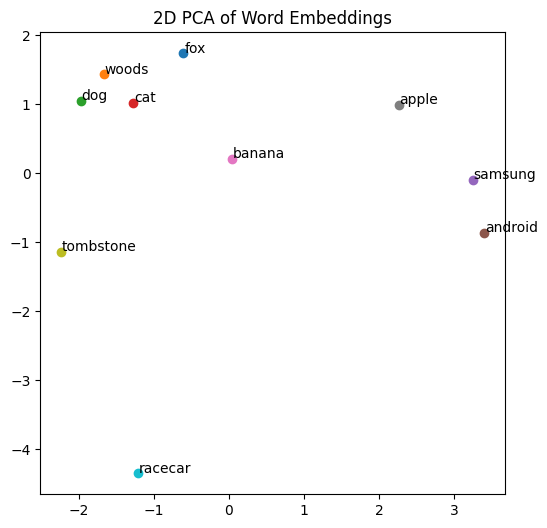

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words_to_visualize = ["fox", "woods", "dog", "cat", "samsung", "android", "banana", "apple", "tombstone","racecar"]
embeddings = [get_embedding_word(w, embedding_model) for w in words_to_visualize]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(6,6))
for i, word in enumerate(words_to_visualize):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)
plt.title("2D PCA of Word Embeddings")
plt.show()

• Explain why cosine similarity is useful in word embedding space.

Words that are semantically similar (in vector form) point in the same direction, regardless of how long they are.
Thus, the consine similarity will be higher between the words.



## Task 3.3 Novel Dissimiliatry Metric

In [8]:
def euclid_dist(vec1, vec2):
    return norm(vec1 - vec2)


## toggle portion for hw check list part with metric=
def compare_pair_words(word, word_list, model, metric="cosine"):


    base_emb = get_embedding_word(word, model)
    results = []
    for w in word_list:
        emb = get_embedding_word(w, model)
        if metric == "cosine":
            score = cosine_similarity(base_emb, emb)
        elif metric == "euclidean":
            score = euclid_dist(base_emb, emb)
        else:
            raise ValueError("Unknown metric")
        results.append((w, score))

    return results

test_word = "banana"
other_words = ["fox", "woods", "dog", "cat", "samsung", "android", "banana", "apple", "tombstone","racecar"]


cosine_results = compare_pair_words(test_word, other_words, embedding_model, metric="cosine")
# Sort descending for cosine
cosine_results = sorted(cosine_results, key=lambda x: x[1], reverse=True)

euclid_results = compare_pair_words(test_word, other_words, embedding_model, metric="euclidean")
# Sort ascending for euclidean
euclid_results = sorted(euclid_results, key=lambda x: x[1], reverse=False)

print("Ranking by Cosine Similarity (higher = more similar):")
for (word, r) in cosine_results:
    print(f"{word}: {s:.4f}")

print("\nRanking by Euclidean Distance (lower = more similar):")
for (word, r) in euclid_results:
    print(f"{word}: {s:.4f}")

Ranking by Cosine Similarity (higher = more similar):
banana: 0.0227
apple: 0.0227
cat: 0.0227
dog: 0.0227
android: 0.0227
fox: 0.0227
tombstone: 0.0227
samsung: 0.0227
woods: 0.0227
racecar: 0.0227

Ranking by Euclidean Distance (lower = more similar):
banana: 0.0227
apple: 0.0227
cat: 0.0227
dog: 0.0227
tombstone: 0.0227
fox: 0.0227
android: 0.0227
woods: 0.0227
samsung: 0.0227
racecar: 0.0227


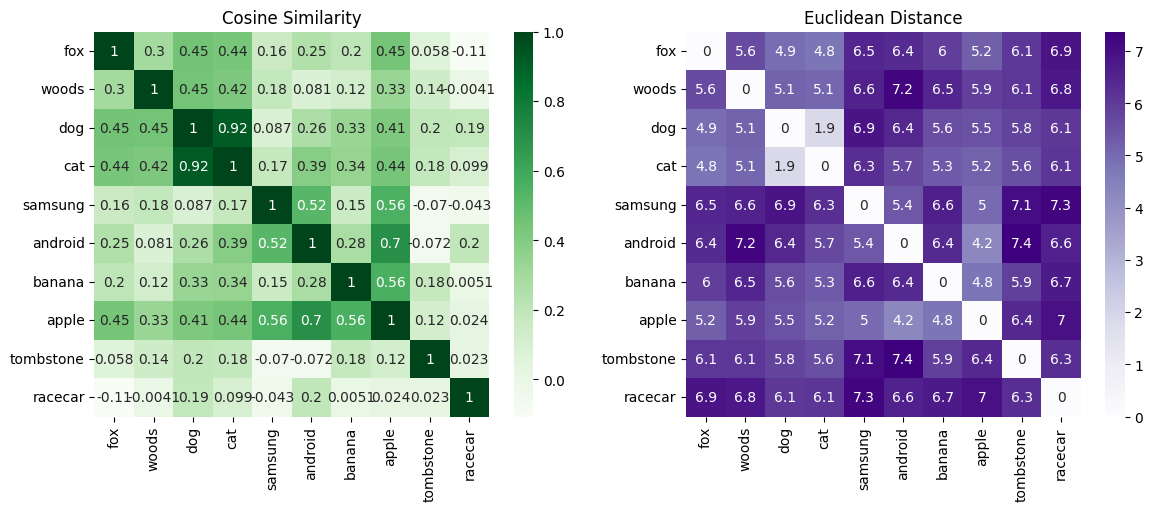

In [11]:
import seaborn as sns
heatmap_words = ["fox", "woods", "dog", "cat", "samsung", "android", "banana", "apple", "tombstone","racecar"]


n = len(heatmap_words)
cosine_matrix = np.zeros((n,n))
euclid_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        emb_i = get_embedding_word(heatmap_words[i], embedding_model)
        emb_j = get_embedding_word(heatmap_words[j], embedding_model)
        cosine_matrix[i,j] = cosine_similarity(emb_i, emb_j)
        euclid_matrix[i,j] = euclid_dist(emb_i, emb_j)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.heatmap(cosine_matrix, annot=True, xticklabels=heatmap_words, yticklabels=heatmap_words, cmap="Greens")
plt.title("Cosine Similarity")

plt.subplot(1,2,2)
sns.heatmap(euclid_matrix, annot=True, xticklabels=heatmap_words, yticklabels=heatmap_words, cmap="Purples")
plt.title("Euclidean Distance")
plt.show()

Explain why your metric captures novelty/diversity better than cosine
similarity alone.

Cosine similarity will tell you if words are on the same general topic.
Euclidean distance will tell you if they are different in every way, including how prominent or common they are, which cosine similarity often ignores.